### CONFIGURAÇÃO E FUNÇÕES

In [1]:
import os
import torchio as tio

# pra usar cpu, descomentar linha abaixo
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import math
import nibabel as nib

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger, EarlyStopping
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, models, Input, Model

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile
from math import ceil
import random
from tensorflow.keras import backend as K
import sys

#import wandb

2026-01-23 06:58:20.339377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-23 06:58:21.020750: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-23 06:58:21.205591: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-23 06:58:22.653882: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%load_ext autoreload
%autoreload 2

# Pega o diretório atual e sobe um nível ('..')
project_root = os.path.abspath('..')

# Adiciona este diretório ao sys.path se ele ainda não estiver lá
if project_root not in sys.path:
    sys.path.append(project_root)

# --- Seus imports originais ---
import utils.processamento_dados as proc_dados
import utils.metricas_e_visualizacao as met_vil

In [3]:
from tensorflow.keras import mixed_precision

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Evita uso excessivo de memória
        print("GPU habilitada com sucesso!")
        print("Memory Growth habilitado para a GPU")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy("mixed_float16")

tf.get_logger().setLevel('ERROR')

GPU habilitada com sucesso!
Memory Growth habilitado para a GPU


I0000 00:00:1769162358.457589  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769162358.463519  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769162358.463573  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# FUNÇÕES
def create_model_3d(input_shape, n_classes):
    inputs = Input(shape=input_shape)  # (D, H, W, C)

    # Camada 1
    x = layers.Conv3D(4, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 2
    x = layers.Conv3D(8, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Camada 3
    x = layers.Conv3D(16, (3, 3, 3), padding='same', kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)
    x = layers.AveragePooling3D(pool_size=(3, 3, 3), padding='same')(x)
    x = layers.Dropout(0.3)(x)

    # Flatten e densas
    x = layers.Flatten()(x)

    x = layers.Dense(16, kernel_regularizer=l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LeakyReLU(negative_slope=0.3)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model

In [5]:
# Definindo caminhos
dir_base = "/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn"

train_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/train'
val_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/validation'
test_dir = f'{dir_base}/ADNI/ADNI_NORMALIZED/test'

fine_tunning_train_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/train'
fine_tunning_val_dir = f'{dir_base}/OASIS/OASIS_1_FSL_NORMALIZED/validation'

results_dir_base = f'{dir_base}/ADNI/ADNI_NORMALIZED/results/fine_tunning_oasis_experiments_final'
os.makedirs(results_dir_base, exist_ok=True)

transformations = ['noise']

In [6]:
n = len(os.listdir(results_dir_base))

if (n > 0):
    if (len(os.listdir(os.path.join(results_dir_base, f'test_experimentos_{n}'))) < 3): 
        for item in os.listdir(os.path.join(results_dir_base, f"test_experimentos_{n}")):
            os.remove(os.path.join(results_dir_base,  f"test_experimentos_{n}", item))
        os.removedirs(os.path.join(results_dir_base, f'test_experimentos_{n}'))
        n -= 1

folder_name = f"test_experimentos_{str(n+1)}"
results_dir = os.path.join(results_dir_base, folder_name)
os.makedirs(results_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_experimentos_5 criada


# Pré-treino

In [7]:
# Nome das classes
# adni_class_names = ['cn', 'mci', 'ad']
adni_class_names = ['cn', 'ad']
# oasis_class_names = ['0.0', '0.5', '1.0']
oasis_class_names = ['0.0', '1.0']

n_adni_classes = len(adni_class_names)
n_oasis_classes = len(oasis_class_names)

# # Experimento 2
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=False,    # Só Geometria
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# Experimento 4
train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
    train_dir, 
    adni_class_names, 
    augment=True, 
    augmentation_factor=3,      # Cria 3 imagens para cada 1 original
    include_intensity=False,    # Só Geometria
    transform_probability=0.3   # 30% chance de transformar, 70% de manter original
)

# # Experimento 6
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=True,     # Geometria + Intensidade
#     transform_probability=1.0   # 100% de chance de transformar (nenhuma original sobra)
# )

# # Experimento 8
# train_images, train_labels, train_paths, class_labels = proc_dados.load_nifti_data_balanced_preallocated(
#     train_dir, 
#     adni_class_names, 
#     augment=True, 
#     augmentation_factor=3,      # Cria 3 imagens para cada 1 original
#     include_intensity=True,    # Geometria + Intensidade
#     transform_probability=0.3   # 30% chance de transformar, 70% de manter original
# )

print(f"N treino: {len(train_paths)}")

val_images, val_labels, val_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(
    val_dir, 
    adni_class_names, 
    augment=False
)

print(f"N validation: {len(val_paths)}")

Passo 1: Analisando diretórios para balanceamento...
   > Classe 'cn': 530 imagens originais encontradas.
   > Classe 'ad': 534 imagens originais encontradas.
   > Alvo de balanceamento: ~1602 imagens por classe.
   > Processando 'cn': Gerando 4 cópias por imagem (Total esperado: 2120)
   > Processando 'ad': Gerando 3 cópias por imagem (Total esperado: 1602)
Total planejado final: 3722 imagens.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 3700/3722
Concluído.
N treino: 3722
Passo 1: Analisando diretórios para balanceamento...
   > Classe 'cn': 137 imagens originais encontradas.
   > Classe 'ad': 152 imagens originais encontradas.
   > Alvo de balanceamento: ~152 imagens por classe.
   > Processando 'cn': Gerando 1 cópias por imagem (Total esperado: 137)
   > Processando 'ad': Gerando 1 cópias por imagem (Total esperado: 152)
Total planejado final: 289 imagens.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Proces

In [8]:
# ==============================================================================
# CONFIGURAÇÃO DA FASE DE TREINAMENTO
# ==============================================================================
# 1 = Pré-treinamento
# 2 = Fine-tuning
fase_atual = 1

# Defina os caminhos base para salvar/carregar
PATH_PRETREINADO = os.path.join(results_dir, "modelo_pretrained.keras")
PATH_FINETUNED = os.path.join(results_dir, "modelo_final.keras")

In [9]:
print("--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---")

# Cria modelo do zero
model = create_model_3d(train_images[0].shape, 2)

# Compilação padrão
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                loss='binary_crossentropy', 
                metrics=['binary_accuracy'])

model.summary()

--- INICIANDO FASE 1: PRÉ-TREINAMENTO ---


I0000 00:00:1769163011.908243  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769163011.908315  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769163011.908335  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769163012.182855  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1769163012.182926  182757 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:21:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-23

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 156, 195, 160,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 156, 195, 160,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 195, 160,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 156, 195, 160,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 52, 65, 54, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 65, 54, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 52, 65, 54, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 65, 54, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 52, 65, 54, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 22, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 22, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 22, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 22, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 22, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 8, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 8, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             

 Total params: 78,410 (306.29 KB)

 Trainable params: 78,322 (305.95 KB)

 Non-trainable params: 88 (352.00 B)

In [10]:
batch_size = 8

steps_per_epoch = math.ceil(len(train_images) / batch_size)
validation_steps = math.ceil(len(val_images) / batch_size)

train_generator = proc_dados.nifti_data_generator_3d(train_images, train_labels, batch_size)
val_generator = proc_dados.nifti_data_generator_3d(val_images, val_labels, batch_size)

# Callbacks
csv_filename = 'log_treino_fase1.csv'
checkpoint_path = PATH_PRETREINADO

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=30, verbose=1),
    # ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
    CSVLogger(os.path.join(results_dir, csv_filename)),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True, mode='max')
]

In [11]:
epochs = 200

print(f"Iniciando treinamento FASE {fase_atual} por {epochs} épocas...")

history_pretrained = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks_list
)

Iniciando treinamento FASE 1 por 200 épocas...
Epoch 1/200


I0000 00:00:1769163027.879157  249375 service.cc:146] XLA service 0x7f8050008b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769163027.879213  249375 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-23 07:10:28.089835: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-23 07:10:28.714175: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2026-01-23 07:10:29.819973: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.1099 = f32[8,18,22,18,8]{4,3,2,1,0} reduce-window(f32[8,52,65,54,8]{4,3,2,1,0} %broadcast.1087, f32[] %constant.1088), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x1_1x0_1x0_0x0_0}, to_apply=%region_1.1095, metadata={op_type="AvgPool3D" op_

465/466 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - binary_accuracy: 0.5385 - loss: 1.2858

2026-01-23 07:11:59.716049: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.273 = f32[2,52,65,54,4]{4,3,2,1,0} reduce-window(f32[2,156,195,160,4]{4,3,2,1,0} %broadcast.261, f32[] %constant.262), window={size=1x3x3x3x1 stride=1x3x3x3x1 pad=0_0x0_0x0_0x1_1x0_0}, to_apply=%region_1.269, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-23 07:12:02.848814: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.132841624s
Constant folding an instructi

466/466 ━━━━━━━━━━━━━━━━━━━━ 124s 169ms/step - binary_accuracy: 0.5525 - loss: 1.2538 - val_binary_accuracy: 0.7993 - val_loss: 1.0113
Epoch 2/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - binary_accuracy: 0.6235 - loss: 1.1198 - val_binary_accuracy: 0.6892 - val_loss: 0.9559
Epoch 3/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - binary_accuracy: 0.6779 - loss: 1.0028 - val_binary_accuracy: 0.8378 - val_loss: 0.8087
Epoch 4/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - binary_accuracy: 0.7182 - loss: 0.9297 - val_binary_accuracy: 0.6332 - val_loss: 1.0823
Epoch 5/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - binary_accuracy: 0.7401 - loss: 0.8790 - val_binary_accuracy: 0.7716 - val_loss: 0.7912
Epoch 6/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 49s 106ms/step - binary_accuracy: 0.7642 - loss: 0.8279 - val_binary_accuracy: 0.8789 - val_loss: 0.6823
Epoch 7/200
466/466 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - binary_accuracy: 0.7687 - loss: 0.7909 - val_binary_accuracy: 0.8478 - val_lo

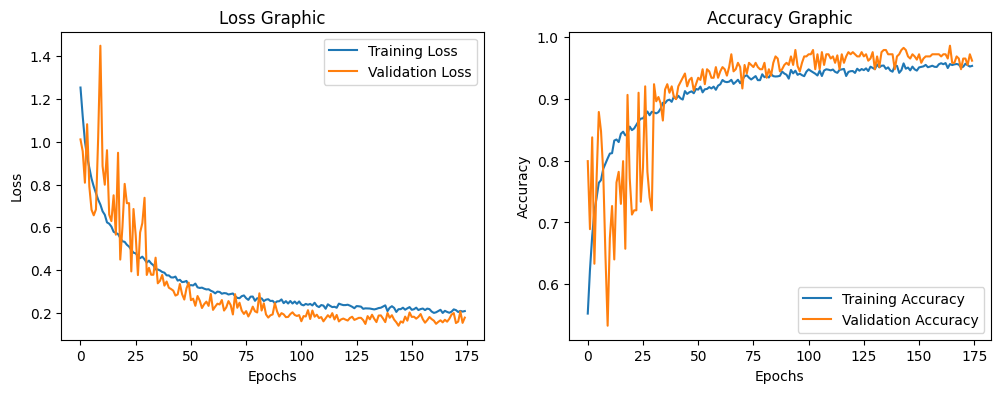

In [12]:
# Plotando o histórico de treinamento após o treinamento
os.makedirs(f"{results_dir}/pretrained", exist_ok=True)
met_vil.plot_training_history(history_pretrained, f"{results_dir}/pretrained", 'pre_training_adni_training_history.png')

### PREDIÇÃO VALIDAÇÃO PRE TREINO

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

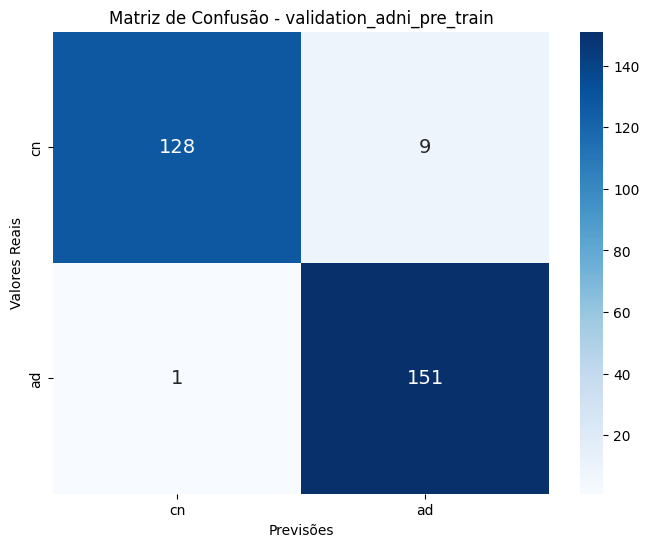

In [13]:
# Realizar predições para dados do conjunto validação
val_pred_labels, val_true_labels, val_pred = met_vil.get_predictions(val_images, val_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, f"{results_dir}/pretrained", 'validation_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
val_pdf_path = os.path.join(f"{results_dir}/pretrained", "validation_adni_predictions_pre_train.pdf")
met_vil.create_pdf(val_paths, val_images, val_true_labels, val_pred_labels, val_pred, val_pdf_path, ["cn", "ad"])

### PREDIÇÃO TESTE PRE TREINO

Passo 1: Analisando diretórios para balanceamento...
   > Classe 'cn': 73 imagens originais encontradas.
   > Classe 'ad': 77 imagens originais encontradas.
   > Alvo de balanceamento: ~77 imagens por classe.
   > Processando 'cn': Gerando 1 cópias por imagem (Total esperado: 73)
   > Processando 'ad': Gerando 1 cópias por imagem (Total esperado: 77)
Total planejado final: 150 imagens.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/150
Concluído.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

2026-01-23 09:39:02.716032: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[6,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[6,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-23 09:39:03.641657: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.925675695s
Trying algorithm eng10{k2=6,k13=0,k14=2,k18=0,k23=0} for conv (f16[6,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[6,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
              precision    recall  f1-score   support

           0       0.99      0.95      0.97        73
           1       0.95      0.99      0.97        77

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



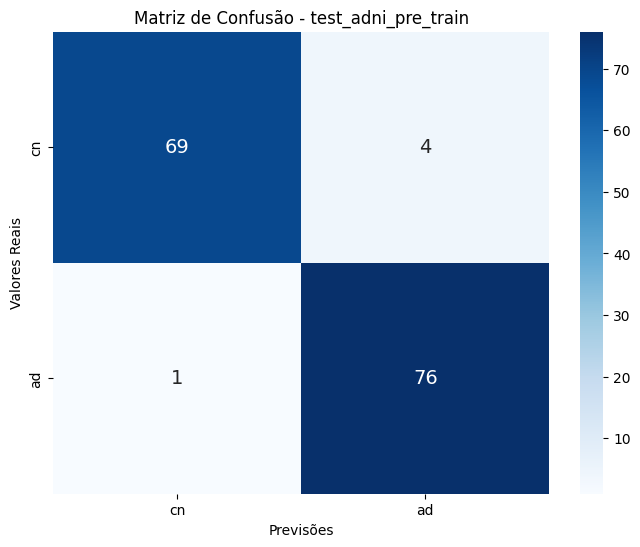

/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/utils/metricas_e_visualizacao.py:132: RuntimeWarning: invalid value encountered in divide
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/utils/metricas_e_visualizacao.py:132: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter


In [14]:
test_images, test_labels, test_paths, _ = proc_dados.load_nifti_data_balanced_preallocated(test_dir, adni_class_names)

# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = met_vil.get_predictions(test_images, test_labels, batch_size, model)

# Obter métricas da valiadação e salvá-las em um arquivo
met_vil.get_classification_report(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train')

# Obter matriz de confusão
met_vil.plot_confusion_matrix(test_true_labels, test_pred_labels, f"{results_dir}/pretrained", 'test_adni_pre_train', ["cn", "ad"])

# Criar pdf com predições
test_pdf_path = os.path.join(f"{results_dir}/pretrained", "test_adni_predictions_pre_train.pdf")
met_vil.create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, ["cn", "ad"])

# Transfer learning

--- CONFIGURAÇÃO EXPERIMENTO (BALANCED CV) ---
Fator de Aumento Alvo: 3x (sobre a classe majoritária)
Incluir Intensidade: False
Probabilidade Transform: 0.3
----------------------------------------------
Carregando dados ORIGINAIS (Raw) para memória...
Passo 1: Analisando diretórios para balanceamento...
   > Classe '0.0': 95 imagens originais encontradas.
   > Classe '1.0': 22 imagens originais encontradas.
   > Alvo de balanceamento: ~95 imagens por classe.
   > Processando '0.0': Gerando 1 cópias por imagem (Total esperado: 95)
   > Processando '1.0': Gerando 1 cópias por imagem (Total esperado: 22)
Total planejado final: 117 imagens.
Passo 2: Detectando shape e Alocando Memória...
Passo 3: Carregando e Processando...
Progresso: 100/117
Concluído.
Total de dados carregados: 117
Pesos calculados: {0: 0.6157894736842106, 1: 2.659090909090909}

INICIANDO FOLD 1/5
   > Steps per Epoch: 57 (Total samples: 456)
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 300ms/step - auc: 0.8082 - binary_accuracy: 0.7346 - loss: 1.1158 - val_auc: 0.5278 - val_binary_accuracy: 0.6250 - val_loss: 1.2708 - learning_rate: 5.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 289ms/step - auc: 0.9325 - binary_accuracy: 0.8531 - loss: 0.7606 - val_auc: 0.9653 - val_binary_accuracy: 0.9167 - val_loss: 0.4814 - learning_rate: 5.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - auc: 0.9531 - binary_accuracy: 0.8706 - loss: 0.6495 - val_auc: 0.9549 - val_binary_accuracy: 0.8750 - val_loss: 0.4012 - learning_rate: 5.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 342ms/step - auc: 0.9551 - binary_accuracy: 0.8969 - loss: 0.5899 - val_auc: 0.9479 - val_binary_accuracy: 0.7917 - val_loss: 0.4441 - learning_rate: 5.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 342ms/step - auc: 0.9669 - binary_accuracy: 0.9035 - loss: 0.5131 - val_auc: 0.9722 - val_binary_accuracy: 0.9167 - val_loss: 0.3233 - learning_rate: 5.0

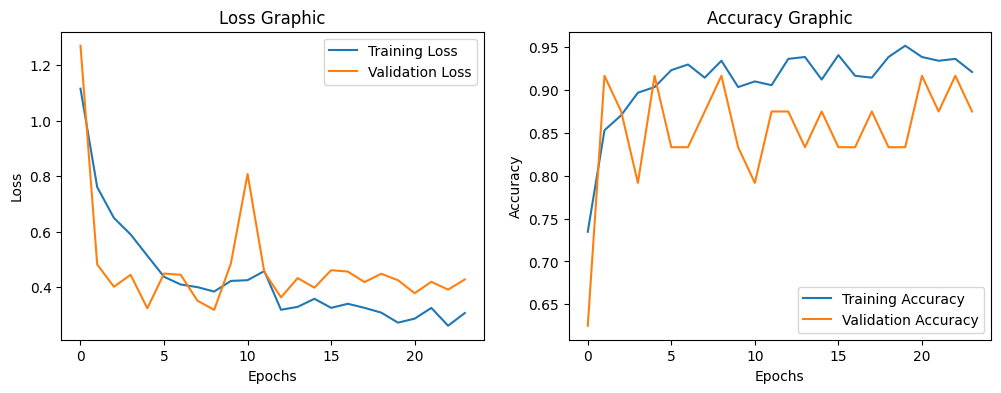

   > Resultado Fold 1: Acc=0.9167, AUC=0.9688
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      0.60      0.75         5

    accuracy                           0.92        24
   macro avg       0.95      0.80      0.85        24
weighted avg       0.92      0.92      0.91        24



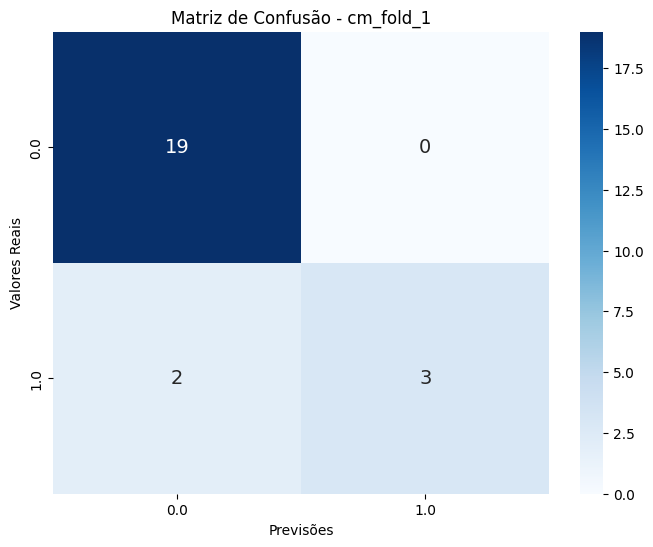


INICIANDO FOLD 2/5
   > Steps per Epoch: 57 (Total samples: 456)
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 323ms/step - auc: 0.8751 - binary_accuracy: 0.8026 - loss: 0.9114 - val_auc: 0.7431 - val_binary_accuracy: 0.7500 - val_loss: 0.7954 - learning_rate: 5.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 267ms/step - auc: 0.9293 - binary_accuracy: 0.8772 - loss: 0.6458 - val_auc: 0.8872 - val_binary_accuracy: 0.8333 - val_loss: 0.5330 - learning_rate: 5.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 337ms/step - auc: 0.9603 - binary_accuracy: 0.8925 - loss: 0.5390 - val_auc: 0.8802 - val_binary_accuracy: 0.7917 - val_loss: 0.5187 - learning_rate: 5.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - auc: 0.9589 - binary_accuracy: 0.9057 - loss: 0.4936 - val_auc: 0.8576 - val_binary_accuracy: 0.7917 - val_loss: 0.5865 - learning_rate: 5.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 308ms/step - auc: 0.9648 - binary_accuracy: 0.9101 - loss: 0.4466 - val_auc: 0.8837 - val_binary_accuracy: 0.8333 - val_loss: 0.5472 - learning_rate: 5.0

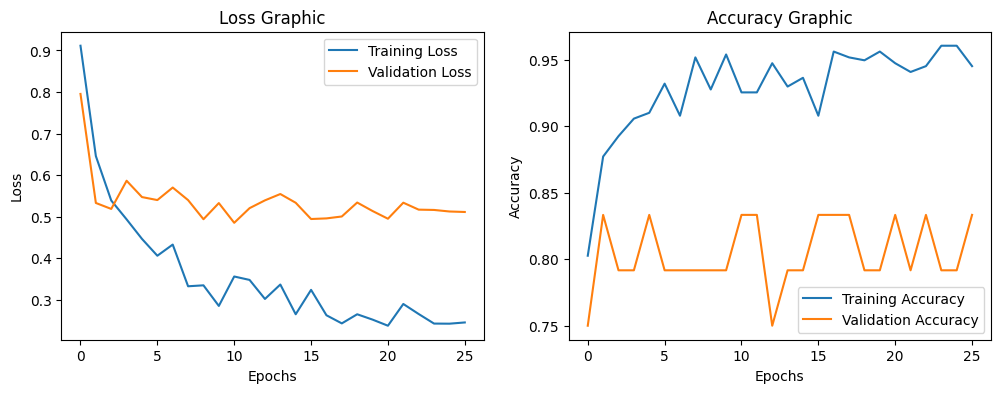

   > Resultado Fold 2: Acc=0.8333, AUC=0.8924
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.60      0.60      0.60         5

    accuracy                           0.83        24
   macro avg       0.75      0.75      0.75        24
weighted avg       0.83      0.83      0.83        24



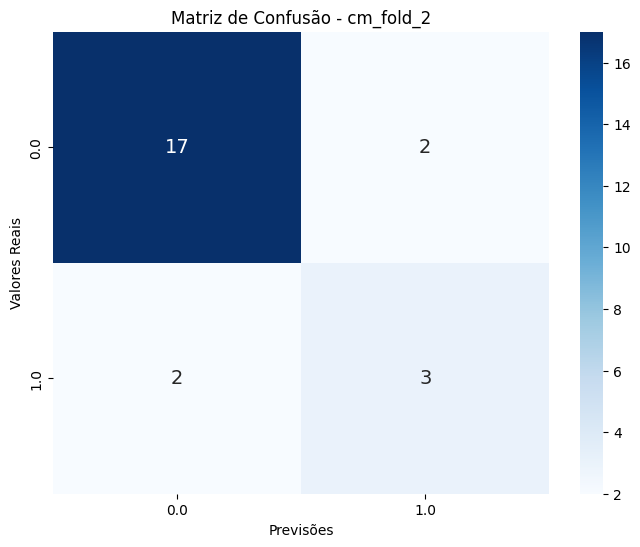


INICIANDO FOLD 3/5
   > Steps per Epoch: 57 (Total samples: 456)
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - auc: 0.7523 - binary_accuracy: 0.6874 - loss: 1.0616

2026-01-23 09:55:17.089217: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[7,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[7,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-23 09:55:17.242709: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.153731981s
Trying algorithm eng10{k2=3,k13=0,k14=2,k18=0,k23=0} for conv (f16[7,4,156,195,160]{4,3,2,1,0}, u8[0]{0}) custom-call(f16[7,1,156,195,160]{4,3,2,1,0}, f16[4,1,3,3,3]{4,3,2,1,0}, f16[4]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_

57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 540ms/step - auc: 0.8296 - binary_accuracy: 0.7478 - loss: 0.8618 - val_auc: 0.3403 - val_binary_accuracy: 0.3478 - val_loss: 2.7892 - learning_rate: 5.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - auc: 0.9189 - binary_accuracy: 0.8596 - loss: 0.5604 - val_auc: 0.8072 - val_binary_accuracy: 0.7391 - val_loss: 0.6952 - learning_rate: 5.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 225ms/step - auc: 0.9381 - binary_accuracy: 0.8706 - loss: 0.5030 - val_auc: 0.8715 - val_binary_accuracy: 0.7826 - val_loss: 0.5663 - learning_rate: 5.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - auc: 0.9529 - binary_accuracy: 0.9013 - loss: 0.4187 - val_auc: 0.9660 - val_binary_accuracy: 0.9130 - val_loss: 0.3334 - learning_rate: 5.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 280ms/step - auc: 0.9508 - binary_accuracy: 0.8904 - loss: 0.4469 - val_auc: 0.9735 - val_binary_accuracy: 0.9130 - val_loss: 0.3316 - learning_rate: 5.000

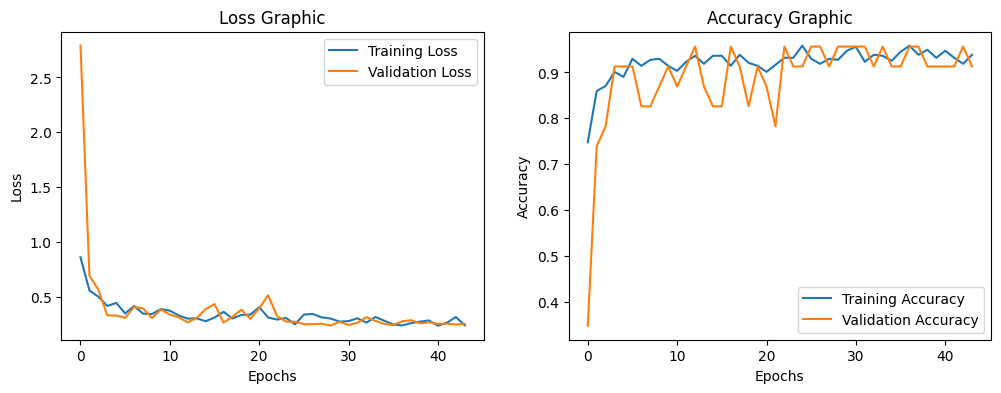

   > Resultado Fold 3: Acc=0.9565, AUC=0.9981
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step  
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.75      0.86         4

    accuracy                           0.96        23
   macro avg       0.97      0.88      0.92        23
weighted avg       0.96      0.96      0.95        23



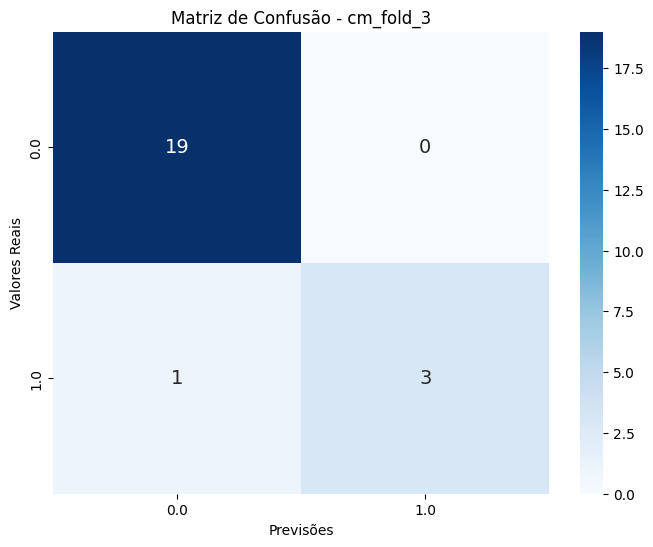


INICIANDO FOLD 4/5
   > Steps per Epoch: 57 (Total samples: 456)
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


57/57 ━━━━━━━━━━━━━━━━━━━━ 29s 366ms/step - auc: 0.8340 - binary_accuracy: 0.7566 - loss: 0.8178 - val_auc: 0.2779 - val_binary_accuracy: 0.3043 - val_loss: 2.4775 - learning_rate: 5.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 309ms/step - auc: 0.9173 - binary_accuracy: 0.8794 - loss: 0.5644 - val_auc: 0.6276 - val_binary_accuracy: 0.6087 - val_loss: 1.0490 - learning_rate: 5.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 359ms/step - auc: 0.9334 - binary_accuracy: 0.8706 - loss: 0.4865 - val_auc: 0.8393 - val_binary_accuracy: 0.7826 - val_loss: 0.5744 - learning_rate: 5.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 345ms/step - auc: 0.9485 - binary_accuracy: 0.9123 - loss: 0.4460 - val_auc: 0.8582 - val_binary_accuracy: 0.7826 - val_loss: 0.5297 - learning_rate: 5.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - auc: 0.9568 - binary_accuracy: 0.9057 - loss: 0.3971 - val_auc: 0.9376 - val_binary_accuracy: 0.8261 - val_loss: 0.4243 - learning_rate: 5.0

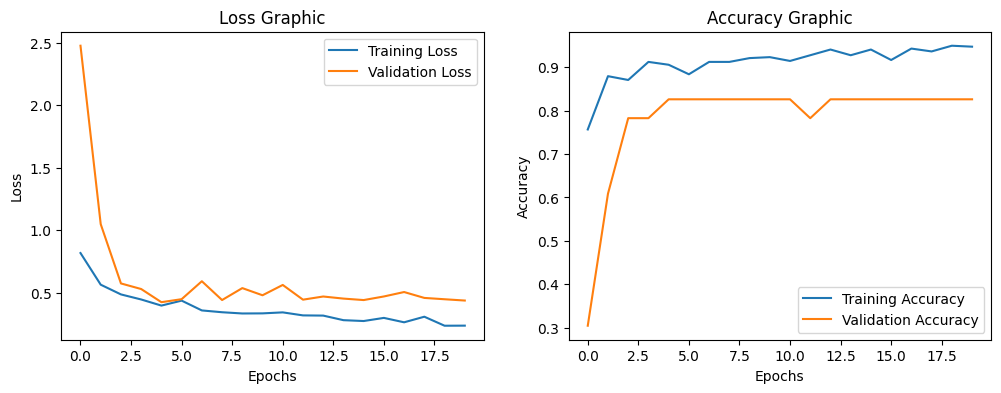

   > Resultado Fold 4: Acc=0.8261, AUC=0.9376
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 875ms/step
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.50      0.50      0.50         4

    accuracy                           0.83        23
   macro avg       0.70      0.70      0.70        23
weighted avg       0.83      0.83      0.83        23



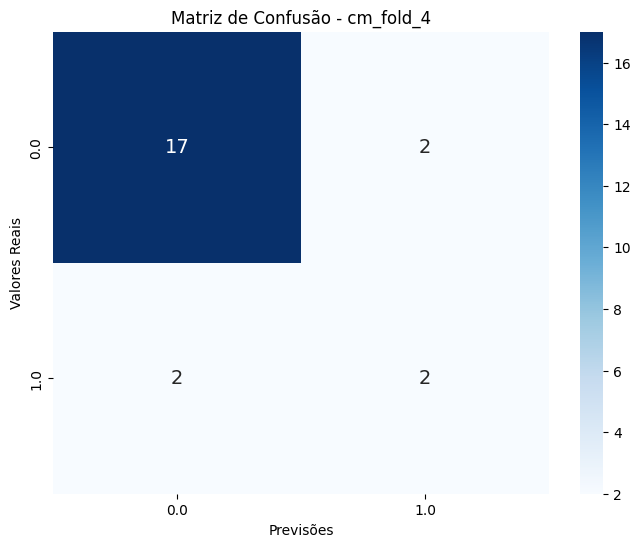


INICIANDO FOLD 5/5
   > Steps per Epoch: 57 (Total samples: 456)
Epoch 1/100


/mnt/c/Users/Paulo Pires/Desktop/Alzheimer_cnn/Alzheimer-CNN-Detection/3dalz/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 325ms/step - auc: 0.8359 - binary_accuracy: 0.7697 - loss: 1.0158 - val_auc: 0.6578 - val_binary_accuracy: 0.6957 - val_loss: 0.9226 - learning_rate: 5.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - auc: 0.9116 - binary_accuracy: 0.8596 - loss: 0.7229 - val_auc: 0.9414 - val_binary_accuracy: 0.8696 - val_loss: 0.4034 - learning_rate: 5.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 287ms/step - auc: 0.9309 - binary_accuracy: 0.8640 - loss: 0.6542 - val_auc: 0.9698 - val_binary_accuracy: 0.8696 - val_loss: 0.3356 - learning_rate: 5.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 303ms/step - auc: 0.9501 - binary_accuracy: 0.8816 - loss: 0.5691 - val_auc: 0.9792 - val_binary_accuracy: 0.8696 - val_loss: 0.2988 - learning_rate: 5.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 286ms/step - auc: 0.9422 - binary_accuracy: 0.8794 - loss: 0.5586 - val_auc: 0.9849 - val_binary_accuracy: 0.9130 - val_loss: 0.2884 - learning_rate: 5.0

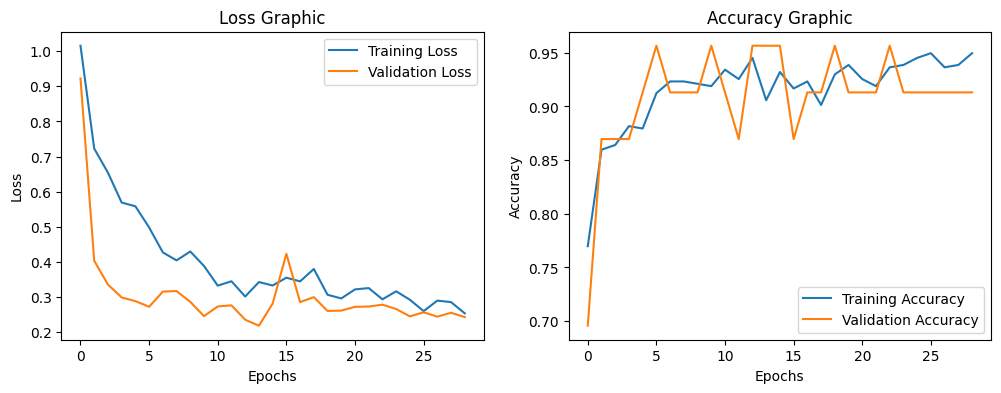

   > Resultado Fold 5: Acc=0.9565, AUC=0.9924
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 856ms/step
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.75      0.86         4

    accuracy                           0.96        23
   macro avg       0.97      0.88      0.92        23
weighted avg       0.96      0.96      0.95        23



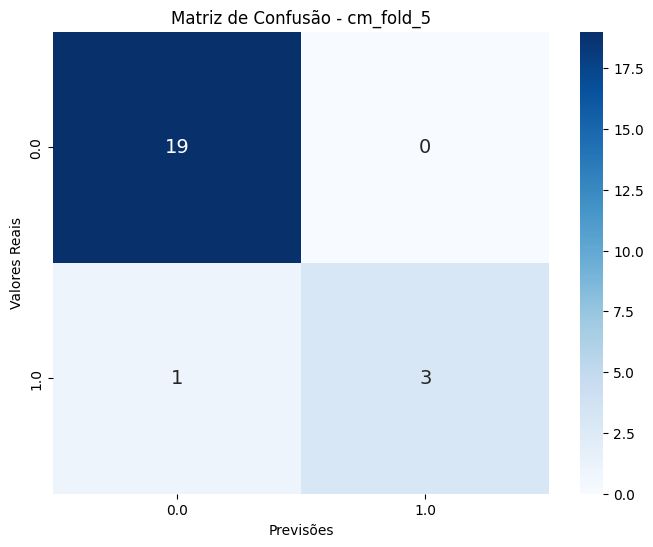

In [15]:
# ==============================================================================
# 1. CONFIGURAÇÃO DOS EXPERIMENTOS
# ==============================================================================
# Experimento 2
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = False    
# EXP_TRANSFORM_PROB = 1.0         

# Experimento 4
EXP_AUGMENTATION_FACTOR = 3
EXP_INCLUDE_INTENSITY = False    
EXP_TRANSFORM_PROB = 0.3

# # Experimento 6
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = True    
# EXP_TRANSFORM_PROB = 1.0  

# # Experimento 8
# EXP_AUGMENTATION_FACTOR = 3
# EXP_INCLUDE_INTENSITY = True    
# EXP_TRANSFORM_PROB = 0.3

print(f"--- CONFIGURAÇÃO EXPERIMENTO (BALANCED CV) ---")
print(f"Fator de Aumento Alvo: {EXP_AUGMENTATION_FACTOR}x (sobre a classe majoritária)")
print(f"Incluir Intensidade: {EXP_INCLUDE_INTENSITY}")
print(f"Probabilidade Transform: {EXP_TRANSFORM_PROB}")
print("----------------------------------------------")

# ==============================================================================
# 2. CARREGAMENTO DOS DADOS CRUS
# ==============================================================================
print("Carregando dados ORIGINAIS (Raw) para memória...")
# Carrega apenas os 117 originais. Isso cabe na RAM tranquilamente.
X_full_raw, y_full_raw_onehot, paths_raw, _ = proc_dados.load_nifti_data_balanced_preallocated(
    fine_tunning_train_dir, 
    oasis_class_names, 
    augment=False 
)
y_full_indices = np.argmax(y_full_raw_onehot, axis=1)
print(f"Total de dados carregados: {len(X_full_raw)}")

# ==============================================================================
# 3. GERADOR DE DADOS
# ==============================================================================
def get_augmentation_pipeline(include_intensity):
    spatial_transforms = tio.Compose([
        tio.RandomAffine(scales=(0.9, 1.1), degrees=15, isotropic=True, p=0.75),
        tio.RandomElasticDeformation(num_control_points=7, max_displacement=7.5, locked_borders=2, p=0.15)
    ])
    
    if include_intensity:
        artifact_transforms = tio.OneOf({
            tio.RandomBiasField(): 0.5, tio.RandomGhosting(): 0.2,
            tio.RandomMotion(degrees=5, translation=5): 0.2,
            tio.RandomNoise(std=0.05): 0.2, tio.RandomBlur(std=(0, 1)): 0.1,
        }, p=0.5)
        pipeline = tio.Compose([spatial_transforms, artifact_transforms])
    else:
        pipeline = spatial_transforms
    return pipeline

def balanced_data_generator(X_data, y_data, factor, include_intensity, prob):
    """
    Gerador que aplica a lógica de balanceamento e augmentation
    imagem por imagem, sem alocar memória extra.
    """
    # 1. Planejamento (Igual ao código anterior, mas só calcula números)
    y_indices = np.argmax(y_data, axis=1)
    unique_classes = np.unique(y_indices)
    class_indices_map = {c: np.where(y_indices == c)[0] for c in unique_classes}
    max_count = max([len(idxs) for idxs in class_indices_map.values()])
    target_count_per_class = max_count * factor
    
    pipeline = get_augmentation_pipeline(include_intensity)
    
    # Lista de tarefas: (indice_original_imagem, deve_transformar_bool)
    # Criamos uma lista de "tarefas" para o epoch inteiro
    tasks = []
    
    for c in unique_classes:
        idxs = class_indices_map[c]
        current_count = len(idxs)
        needed = target_count_per_class
        copies_per_img = needed // current_count
        remainder = needed % current_count
        
        for i_idx, original_idx in enumerate(idxs):
            n_copies = copies_per_img + (1 if i_idx < remainder else 0)
            for _ in range(n_copies):
                # Decide agora se essa cópia será transformada ou não
                should_transform = (random.random() < prob)
                tasks.append((original_idx, should_transform))
                
    # Loop infinito do gerador (obrigatório para Keras fit)
    while True:
        random.shuffle(tasks) # Embaralha a cada época
        
        for original_idx, do_transform in tasks:
            img_arr = X_data[original_idx] # Pega da RAM (rápido)
            lbl = y_data[original_idx]
            
            final_img = None
            
            if do_transform:
                # Augmentation On-the-fly
                img_tensor = img_arr.astype(np.float32)
                subject = tio.Subject(mri=tio.ScalarImage(tensor=np.moveaxis(img_tensor, -1, 0)))
                transformed = pipeline(subject)
                res_data = transformed.mri.data.numpy()
                final_img = np.moveaxis(res_data, 0, -1).astype(np.float16)
            else:
                final_img = img_arr
            
            # Yield (Entrega 1 exemplo)
            yield final_img, lbl

# ==============================================================================
# 4. LOOP 5-FOLD CROSS VALIDATION
# ==============================================================================
K_FOLDS = 5
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

fold_accuracies = []
fold_aucs = []
aggregated_true_labels = []
aggregated_pred_labels = []

# BATCH SIZE SEGURO (Mantenha baixo para 3D)
BATCH_SIZE = 8
EPOCHS = 100 

# Pega o shape de uma imagem para configurar o TF Dataset
sample_shape = X_full_raw[0].shape
n_classes_oasis = y_full_raw_onehot.shape[1]

y_inteiros = np.argmax(y_full_raw_onehot, axis=1)
pesos = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_inteiros),
    y=y_inteiros
)
class_weights_dict = dict(enumerate(pesos))
print(f"Pesos calculados: {class_weights_dict}")

for fold_idx, (train_index, val_index) in enumerate(skf.split(X_full_raw, y_full_indices)):
    print(f"\n{'='*40}")
    print(f"INICIANDO FOLD {fold_idx+1}/{K_FOLDS}")
    print(f"{'='*40}")

    fold_dir = os.path.join(results_dir, f"fase2_fold_{fold_idx+1}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- A. Split ---
    X_train_fold = X_full_raw[train_index]
    y_train_fold = y_full_raw_onehot[train_index]
    
    X_val_fold = X_full_raw[val_index]
    y_val_fold = y_full_raw_onehot[val_index]

    # --- B. Configuração do Dataset (Generator) ---
    # Calcula quantos passos por época (Total de imagens geradas / Batch)
    # Recalculando o total esperado baseado na lógica do generator
    max_cnt = 0
    y_tr_idx = np.argmax(y_train_fold, axis=1)
    for c in np.unique(y_tr_idx):
        max_cnt = max(max_cnt, np.sum(y_tr_idx == c))
    total_train_samples = (max_cnt * EXP_AUGMENTATION_FACTOR) * len(np.unique(y_tr_idx))
    
    steps_per_epoch = math.ceil(total_train_samples / BATCH_SIZE)
    print(f"   > Steps per Epoch: {steps_per_epoch} (Total samples: {total_train_samples})")

    # Cria o objeto tf.data.Dataset
    train_dataset = tf.data.Dataset.from_generator(
        lambda: balanced_data_generator(
            X_train_fold, y_train_fold, 
            EXP_AUGMENTATION_FACTOR, EXP_INCLUDE_INTENSITY, EXP_TRANSFORM_PROB
        ),
        output_signature=(
            tf.TensorSpec(shape=sample_shape, dtype=tf.float16),
            tf.TensorSpec(shape=(n_classes_oasis,), dtype=tf.float16)
        )
    )
    
    # Otimizações do Dataset
    train_dataset = train_dataset.batch(BATCH_SIZE)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

    # --- C. Modelo ---
    if not os.path.exists(PATH_PRETREINADO):
        raise FileNotFoundError(f"Modelo base não encontrado: {PATH_PRETREINADO}")
    
    K.clear_session()
    base_model = load_model(PATH_PRETREINADO)

    x = base_model.layers[-2].output 
    predictions = layers.Dense(n_oasis_classes, activation='softmax', name='new_output')(x)
    model = models.Model(inputs=base_model.input, outputs=predictions)

    for layer in model.layers[:7]:
        layer.trainable = False
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                  loss='binary_crossentropy', 
                  metrics=['binary_accuracy', tf.keras.metrics.AUC(name='auc')])

    # --- D. Treino ---
    checkpoint_path_fold = os.path.join(fold_dir, f"best_model_fold_{fold_idx+1}.keras")
    csv_log_fold = os.path.join(fold_dir, 'training_log.csv')
    
    callbacks_list = [
        EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        CSVLogger(csv_log_fold),
        ModelCheckpoint(filepath=checkpoint_path_fold, monitor='val_binary_accuracy', save_best_only=True, mode='max')
    ]

    history = model.fit(
        train_dataset,
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        verbose=1,
        validation_data=(X_val_fold, y_val_fold), 
        batch_size=BATCH_SIZE,
        callbacks=callbacks_list,
        class_weight=class_weights_dict
    )

    # --- E. Avaliação ---
    print("Gerando métricas do fold...")
    met_vil.plot_training_history(history, fold_dir)

    loss, acc, auc = model.evaluate(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, verbose=0)
    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    print(f"   > Resultado Fold {fold_idx+1}: Acc={acc:.4f}, AUC={auc:.4f}")

    val_pred_probs = model.predict(X_val_fold, batch_size=BATCH_SIZE)
    val_pred_labels = np.argmax(val_pred_probs, axis=1)
    val_true_labels = np.argmax(y_val_fold, axis=1)

    met_vil.get_classification_report(val_true_labels, val_pred_labels, fold_dir, f'report_fold_{fold_idx+1}')
    met_vil.plot_confusion_matrix(val_true_labels, val_pred_labels, fold_dir, f'cm_fold_{fold_idx+1}', oasis_class_names)

    aggregated_true_labels.extend(val_true_labels)
    aggregated_pred_labels.extend(val_pred_labels)

    # --- F. Limpeza ---
    del model, base_model, train_dataset, X_train_fold, X_val_fold
    K.clear_session()
    gc.collect()

### RESULTADOS GLOBAIS


=== VALIDAÇÃO CRUZADA FINALIZADA ===
Acurácia Média: 0.8978 (+/- 0.0575)
AUC Média: 0.9579 (+/- 0.0391)


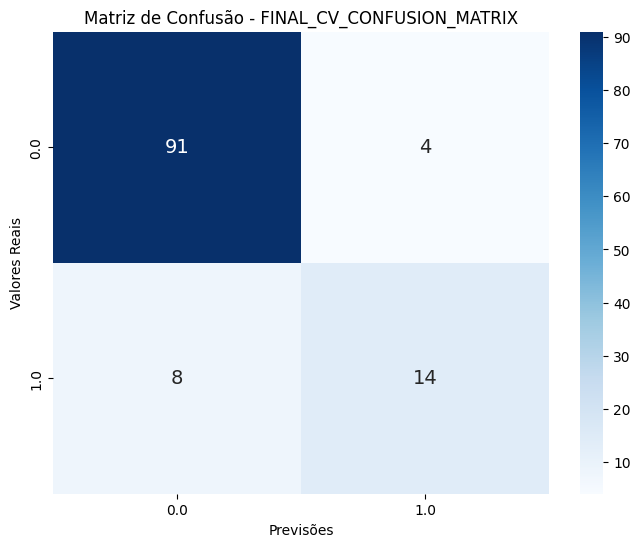

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        95
           1       0.78      0.64      0.70        22

    accuracy                           0.90       117
   macro avg       0.85      0.80      0.82       117
weighted avg       0.89      0.90      0.89       117



In [16]:
# ==============================================================================
# 5. RESULTADOS GLOBAIS
# ==============================================================================
print("\n=== VALIDAÇÃO CRUZADA FINALIZADA ===")
print(f"Acurácia Média: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"AUC Média: {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")

aggregated_true = np.array(aggregated_true_labels)
aggregated_pred = np.array(aggregated_pred_labels)

met_vil.plot_confusion_matrix(
    aggregated_true, 
    aggregated_pred, 
    results_dir, 
    'FINAL_CV_CONFUSION_MATRIX', 
    oasis_class_names
)

met_vil.get_classification_report(
    aggregated_true, 
    aggregated_pred, 
    results_dir, 
    'FINAL_CV_REPORT'
)